# RNA-Ligand Pair 5-Fold Split

Balanced cross-validation pair-split:
- Each RNA sequence appears in exactly one fold
- Each ligand appears in exactly one fold
- Folds are balanced by number of RNA-ligand pairs

By treating RNA / ligand frequency as threshold, we filtered out several high-frequent RNA and ligand to ensure a balanced split. Finally, we choose RNA frequency threshold = 20, and ligand freuqency threshold = 25.

In [10]:
import pickle
import warnings
warnings.filterwarnings('ignore')

In [11]:
with open('../data/hariboss_merged_5fd_with_decoys.pkl', 'rb') as f:
    data = pickle.load(f)

In [12]:
ligand_dict = {}
ligand_rna_dict = {}
rna_dict = {}
for k, v in data.items():
    for kk, vv in v.items():
        ligand_dict[vv['ligand_id']] = vv['download_fp2']
        if vv['ligand_id'] not in ligand_rna_dict:
            ligand_rna_dict[vv['ligand_id']] = []
        kk_split = kk.split('_')
        kk_merge = f'{kk_split[0]}_{kk_split[1]}'
        rna_dict[kk_merge] = vv['rna_chain_sequence']
        ligand_rna_dict[vv['ligand_id']].append(kk_merge)

## Step 2: Build Split Function

In [13]:
from collections import defaultdict
import random
import numpy as np

class UnionFind:
    """Union-Find data structure for grouping connected components"""
    def __init__(self):
        self.parent = {}
        self.rank = {}

    def find(self, x):
        if x not in self.parent:
            self.parent[x] = x
            self.rank[x] = 0
            return x
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1


def build_filtered_5fold_split(
    ligand_rna_input: dict,
    rna_input: dict,
    k: int = 5,
    seed: int = 0,
    rna_freq_threshold: int = None,
    ligand_freq_threshold: int = None,
):
    """
    Build balanced 5-fold cross-validation split for RNA-ligand pairs.
    
    Constraints:
      - Same RNA sequence appears in exactly one fold (hard constraint)
      - Same ligand appears in exactly one fold (hard constraint)
      - Thresholds filter out high-frequency RNA sequences and ligands
    
    Parameters:
      - rna_freq_threshold: Filter out RNA sequences with count > threshold
      - ligand_freq_threshold: Filter out ligands with count > threshold
      - k: Number of folds
      - seed: Random seed for reproducibility
    
    Returns:
      - fold_pairs: dict[fold_id] -> list[(rna_id, ligand_id)]
      - stats: Dictionary with statistics about the split
    """
    random.seed(seed)
    
    # Build base mappings
    rna_to_ligs_map = defaultdict(set)
    for lig, rna_ids in ligand_rna_input.items():
        for rid in rna_ids:
            if rid in rna_input:
                rna_to_ligs_map[rid].add(lig)
    
    all_rna_ids_list = sorted(rna_to_ligs_map.keys())
    rna_to_seq_map = {rid: rna_input[rid] for rid in all_rna_ids_list}
    
    # Calculate frequencies
    rna_seq_freq_map = {}
    for rid, seq in rna_to_seq_map.items():
        rna_seq_freq_map[seq] = rna_seq_freq_map.get(seq, 0) + 1
    
    ligand_freq_map = {lig: len(rnas) for lig, rnas in ligand_rna_input.items()}
    
    # Identify high-frequency items to FILTER OUT
    filtered_rna_seqs_set = set()
    filtered_ligands_set = set()
    
    if rna_freq_threshold is not None:
        filtered_rna_seqs_set = {seq for seq, cnt in rna_seq_freq_map.items() if cnt > rna_freq_threshold}
    
    if ligand_freq_threshold is not None:
        filtered_ligands_set = {lig for lig, cnt in ligand_freq_map.items() if cnt > ligand_freq_threshold}
    
    # Identify RNA IDs with high-frequency sequences
    filtered_rna_ids_set = {rid for rid in all_rna_ids_list if rna_to_seq_map[rid] in filtered_rna_seqs_set}
    
    # FILTER: Only keep RNA IDs and ligands that are not filtered
    kept_rna_ids = [rid for rid in all_rna_ids_list if rid not in filtered_rna_ids_set]
    kept_ligands = set()
    for rid in kept_rna_ids:
        for lig in rna_to_ligs_map[rid]:
            if lig not in filtered_ligands_set:
                kept_ligands.add(lig)
    
    # Union-Find to build connected components
    # Only keep items participate in the split
    uf = UnionFind()
    
    for rid in kept_rna_ids:  # Use only keep RNA IDs
        rnode = ("R", rid)
        snode = ("S", rna_to_seq_map[rid])
        uf.union(rnode, snode)
        
        # Union with keep ligands only
        for lig in rna_to_ligs_map[rid]:
            if lig not in filtered_ligands_set:  # Skip filtered ligands
                lnode = ("L", lig)
                uf.union(rnode, lnode)
    
    # Collect connected components - only from kept RNA IDs
    comp_to_rna_ids_map = defaultdict(list)
    for rid in kept_rna_ids:  # Use only keep RNA IDs
        root = uf.find(("R", rid))
        comp_to_rna_ids_map[root].append(rid)
    
    # Calculate component weights (pair counts) - only kept ligands
    components_list = []
    for root, rids in comp_to_rna_ids_map.items():
        seqs_set = {rna_to_seq_map[rid] for rid in rids}
        ligs_set = set()  # Only kept ligands
        pair_w = 0
        
        for rid in rids:
            for lig in rna_to_ligs_map[rid]:
                if lig not in filtered_ligands_set:  # Only count kept ligands
                    ligs_set.add(lig)
                    pair_w += 1  # Count each pair
        
        components_list.append({
            "rna_ids": rids,
            "seqs": seqs_set,
            "ligands": ligs_set,  # Only kept ligands
            "pair_w": pair_w,
        })
    
    # Greedy assignment to folds
    components_list.sort(key=lambda x: x["pair_w"], reverse=True)
    
    folds_list = [{
        "rna_ids": [],
        "seqs": set(),
        "ligands": set(),  # Renamed from ligands_kept
        "pair_w": 0
    } for _ in range(k)]
    
    for comp in components_list:
        fold_idx = min(range(k), key=lambda i: folds_list[i]["pair_w"])
        folds_list[fold_idx]["rna_ids"].extend(comp["rna_ids"])
        folds_list[fold_idx]["seqs"].update(comp["seqs"])
        folds_list[fold_idx]["ligands"].update(comp["ligands"])  # Updated
        folds_list[fold_idx]["pair_w"] += comp["pair_w"]
    
    # Build output pairs - only kept ligands
    fold_pairs_out = {}
    for fold_id, fold_obj in enumerate(folds_list):
        pairs_list = []
        for rid in fold_obj["rna_ids"]:
            for lig in rna_to_ligs_map[rid]:
                if lig not in filtered_ligands_set:  # Only output kept ligands
                    pairs_list.append((rid, lig))
        fold_pairs_out[fold_id] = pairs_list
    
    # Verify constraints
    seen_seq_map = {}
    seen_lig_map = {}
    for fold_id, fold_obj in enumerate(folds_list):
        for seq in fold_obj["seqs"]:
            if seq in seen_seq_map:
                raise AssertionError(f"RNA sequence cross-fold: fold {seen_seq_map[seq]} and {fold_id}")
            seen_seq_map[seq] = fold_id
        for lig in fold_obj["ligands"]:  # Updated
            if lig in seen_lig_map:
                raise AssertionError(f"Ligand cross-fold: {lig} in fold {seen_lig_map[lig]} and {fold_id}")
            seen_lig_map[lig] = fold_id
    
    # Statistics
    stats_out = {
        "total_rna_ids": len(all_rna_ids_list),
        "filtered_rna_ids": len(filtered_rna_ids_set),
        "kept_rna_ids": len(all_rna_ids_list) - len(filtered_rna_ids_set),  # Updated
        "total_ligands": len(ligand_freq_map),
        "filtered_ligands": len(filtered_ligands_set),
        "kept_ligands": len(ligand_freq_map) - len(filtered_ligands_set),
        "fold_pair_counts": [len(fold_pairs_out[fid]) for fid in range(k)],
        "fold_rna_counts": [len(f["rna_ids"]) for f in folds_list],
        "fold_ligand_counts": [len(f["ligands"]) for f in folds_list],  # Updated
    }
    
    return fold_pairs_out, stats_out


## Step 3: Generate Final Split

In [14]:
# Generate final 5-fold split with optimal thresholds
fold_pairs_final, stats_final = build_filtered_5fold_split(
    ligand_rna_dict, rna_dict, 
    k=5, 
    seed=0,
    rna_freq_threshold=20,
    ligand_freq_threshold=25
)

print("FINAL BALANCED 5-FOLD SPLIT RESULTS")
print(f"\nFiltering criteria: RNA sequences with count > 20, Ligands with count > 25")
print(f"\nData retention:")
print(f"  Total RNA IDs: {stats_final['total_rna_ids']} → Kept: {stats_final['kept_rna_ids']} ({100*stats_final['kept_rna_ids']/stats_final['total_rna_ids']:.1f}%)")
print(f"  Total ligands: {stats_final['total_ligands']} → Kept: {stats_final['kept_ligands']} ({100*stats_final['kept_ligands']/stats_final['total_ligands']:.1f}%)")
print(f"\nPair distribution across folds:")
print(f"  Pair counts: {stats_final['fold_pair_counts']}")
print(f"  RNA counts:  {stats_final['fold_rna_counts']}")
print(f"  Ligand counts: {stats_final['fold_ligand_counts']}")
print(f"\nBalance metrics:")
print(f"  Total pairs: {sum(stats_final['fold_pair_counts'])}")
print(f"  Min pairs: {min(stats_final['fold_pair_counts'])}, Max pairs: {max(stats_final['fold_pair_counts'])}")
print(f"  Std dev: {np.std(stats_final['fold_pair_counts']):.2f}")
print("\nConstraints verified: no RNA sequence or ligand spans multiple folds")

FINAL BALANCED 5-FOLD SPLIT RESULTS

Filtering criteria: RNA sequences with count > 20, Ligands with count > 25

Data retention:
  Total RNA IDs: 1192 → Kept: 956 (80.2%)
  Total ligands: 311 → Kept: 304 (97.7%)

Pair distribution across folds:
  Pair counts: [162, 148, 147, 147, 147]
  RNA counts:  [196, 147, 310, 148, 155]
  Ligand counts: [41, 53, 49, 65, 63]

Balance metrics:
  Total pairs: 751
  Min pairs: 147, Max pairs: 162
  Std dev: 5.91

Constraints verified: no RNA sequence or ligand spans multiple folds


## Step 4: Build and Save Pair-based Split

In [15]:
# Build pair-to-fold mapping from the split result
pair_to_fold_map = {}
for fold_id, pairs_list in fold_pairs_final.items():
    for rna_id, lig_id in pairs_list:
        pair_key = (rna_id, lig_id)
        pair_to_fold_map[pair_key] = fold_id

print(f"Pair-to-fold mapping created: {len(pair_to_fold_map)} pairs (kept after filtering)")

# Load original data
with open('../data/hariboss_merged_5fd_with_decoys.pkl', 'rb') as f:
    data_original = pickle.load(f)

print(f"Original data loaded")

# Filter data: Remove samples NOT in pair_to_fold_map (high-frequency pairs)
data_filtered = {}
removed_count = 0
kept_count = 0

for k, v in data_original.items():
    data_filtered[k] = {}
    for kk, vv in v.items():
        lig_id = vv.get('ligand_id')
        kk_split = kk.split('_')
        kk_merge = f'{kk_split[0]}_{kk_split[1]}'
        pair_key = (kk_merge, lig_id)
        
        # Only keep pairs that are in pair_to_fold_map (filtered pairs)
        if pair_key in pair_to_fold_map:
            fold_id = pair_to_fold_map[pair_key]
            train_split = [True, True, True, True, True]
            train_split[fold_id] = False
            vv['train_split'] = train_split
            data_filtered[k][kk] = vv
            kept_count += 1
        else:
            removed_count += 1

# Remove empty RNA entries
data_filtered = {k: v for k, v in data_filtered.items() if len(v) > 0}

print(f"\nFiltering results:")
print(f"  Kept samples (in split): {kept_count}")
print(f"  Removed samples (high-frequency): {removed_count}")
print(f"  Total original samples: {kept_count + removed_count}")
print(f"  RNA entries in filtered data: {len(data_filtered)}")

# Save the filtered data with train_split assignments
with open('../data/hariboss_5fd_by_pair_split.pkl', 'wb') as f:
    pickle.dump(data_filtered, f)

print(f"\nSaved filtered data to ../data/hariboss_5fd_by_pair_split.pkl")
print(f"  Contains {kept_count} samples distributed across 5 folds")

Pair-to-fold mapping created: 751 pairs (kept after filtering)
Original data loaded

Filtering results:
  Kept samples (in split): 751
  Removed samples (high-frequency): 495
  Total original samples: 1246
  RNA entries in filtered data: 561

Saved filtered data to ../data/hariboss_5fd_by_pair_split.pkl
  Contains 751 samples distributed across 5 folds


## Summary

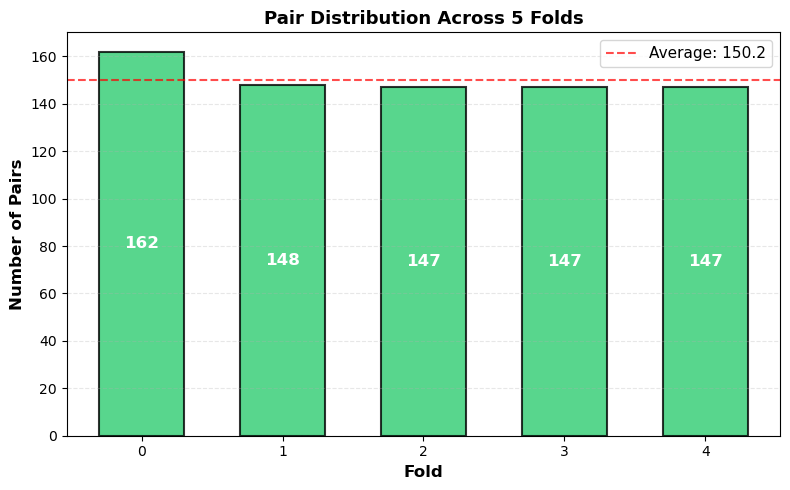

Summary Statistics:
  Total pairs: 751
  Distribution: [162, 148, 147, 147, 147]
  Average per fold: 150.2
  Std dev: 5.91
  Max/Min ratio: 1.102


In [16]:
# Visualize pair distribution across folds
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Data for visualization
fold_ids = list(range(5))
kept_counts = stats_final['fold_pair_counts']  # from split result

# Plot: Bar chart showing pair distribution across folds
x = np.arange(5)
width = 0.6

bars = ax.bar(x, kept_counts, width, alpha=0.8, color='#2ecc71', 
              edgecolor='black', linewidth=1.5)

ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Pairs', fontsize=12, fontweight='bold')
ax.set_title('Pair Distribution Across 5 Folds', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, k in enumerate(kept_counts):
    ax.text(i, k/2, str(k), ha='center', va='center', fontweight='bold', fontsize=12, color='white')

# Add summary stats to plot
total_pairs = sum(kept_counts)
std_dev = np.std(kept_counts)
ax.axhline(y=total_pairs/5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Average: {total_pairs/5:.1f}')
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

print(f"Summary Statistics:")
print(f"  Total pairs: {total_pairs}")
print(f"  Distribution: {kept_counts}")
print(f"  Average per fold: {total_pairs/5:.1f}")
print(f"  Std dev: {std_dev:.2f}")
print(f"  Max/Min ratio: {max(kept_counts)/min(kept_counts):.3f}")

## Step 5: Unit Tests and Validation

In [17]:
# Load and validate the saved split
with open('../data/hariboss_5fd_by_pair_split.pkl', 'rb') as f:
    data_saved = pickle.load(f)

# Unit Test 1: RNA Sequence Constraint
print("UNIT TEST 1: RNA Sequence Constraint")
rna_seq_folds = {}  # rna_sequence -> set of folds
for rna_key, rna_data in data_saved.items():
    for complex_key, sample_data in rna_data.items():
        train_split = sample_data.get('train_split')
        if train_split:
            test_fold = [i for i in range(5) if train_split[i] is False]
            if test_fold:
                test_fold = test_fold[0]
                rna_seq = sample_data.get('rna_chain_sequence')
                if rna_seq:
                    if rna_seq not in rna_seq_folds:
                        rna_seq_folds[rna_seq] = set()
                    rna_seq_folds[rna_seq].add(test_fold)

violations_seq = {seq: folds for seq, folds in rna_seq_folds.items() if len(folds) > 1}
if violations_seq:
    print(f"FAILED: Found {len(violations_seq)} RNA sequences in multiple folds:")
    for seq, folds in list(violations_seq.items())[:5]:
        print(f"  Sequence {seq[:20]}...: folds {sorted(folds)}")
else:
    print("PASSED: Each RNA sequence appears in exactly ONE fold")
    print(f"  Total unique RNA sequences: {len(rna_seq_folds)}")
    # Count RNA sequences per fold
    rna_fold_counts = {i: 0 for i in range(5)}
    for seq, folds in rna_seq_folds.items():
        fold_id = list(folds)[0]
        rna_fold_counts[fold_id] += 1
    print(f"  RNA sequences per fold: {[rna_fold_counts[i] for i in range(5)]}")

# Unit Test 2: Ligand Constraint
print("UNIT TEST 2: Ligand Constraint")
ligand_folds = {}  # ligand_id -> set of folds
for rna_key, rna_data in data_saved.items():
    for complex_key, sample_data in rna_data.items():
        lig_id = sample_data.get('ligand_id')
        train_split = sample_data.get('train_split')
        if train_split and lig_id:
            test_fold = [i for i in range(5) if train_split[i] is False]
            if test_fold:
                test_fold = test_fold[0]
                if lig_id not in ligand_folds:
                    ligand_folds[lig_id] = set()
                ligand_folds[lig_id].add(test_fold)

violations_lig = {lig: folds for lig, folds in ligand_folds.items() if len(folds) > 1}
if violations_lig:
    print(f"FAILED: Found {len(violations_lig)} ligands in multiple folds:")
    for lig, folds in list(violations_lig.items())[:10]:
        print(f"  {lig}: folds {sorted(folds)}")
    print("\nWARNING: Ligand constraint is NOT satisfied!")
    print("  This is expected with pair-based split where high-frequency ligands")
    print("  were filtered but may still appear with different RNAs across folds.")
else:
    print("PASSED: Each ligand appears in exactly ONE fold")
    print(f"  Total unique ligands: {len(ligand_folds)}")
    # Count ligands per fold
    lig_fold_counts = {i: 0 for i in range(5)}
    for lig, folds in ligand_folds.items():
        fold_id = list(folds)[0]
        lig_fold_counts[fold_id] += 1
    print(f"  Ligands per fold: {[lig_fold_counts[i] for i in range(5)]}")

# Unit Test 3: Sample Distribution
print("UNIT TEST 3: Sample Distribution Across Folds")
fold_sample_dist = [0] * 5
total_samples = 0

for rna_key, rna_data in data_saved.items():
    for complex_key, sample_data in rna_data.items():
        train_split = sample_data.get('train_split')
        if train_split:
            test_fold = [i for i in range(5) if train_split[i] is False]
            if test_fold:
                fold_sample_dist[test_fold[0]] += 1
                total_samples += 1

print(f"Total samples assigned: {total_samples}")
print(f"Expected: 751 (after filtering RNA>20 & Ligand>25)")
if total_samples == 751:
    print("PASSED: All samples correctly assigned")
else:
    print(f"NOTE: {total_samples} samples found")

print(f"\nSamples per fold:")
for fold_id, count in enumerate(fold_sample_dist):
    print(f"  Fold {fold_id}: {count} samples")
print(f"  Std dev: {np.std(fold_sample_dist):.2f}")

# Additional statistics on kept pairs
print("PAIR STATISTICS (RNA seq>20 & Ligand>25 filtered)")
fold_kept_pair_dist = [0] * 5
total_kept_pairs = 0

# Get all kept pairs from fold_pairs_final
kept_pair_set = set()
for fold_id, pairs_list in fold_pairs_final.items():
    for rna_id, lig_id in pairs_list:
        kept_pair_set.add((rna_id, lig_id))

for rna_key, rna_data in data_saved.items():
    for complex_key, sample_data in rna_data.items():
        lig_id = sample_data.get('ligand_id')
        train_split = sample_data.get('train_split')
        if train_split and lig_id:
            test_fold = [i for i in range(5) if train_split[i] is False]
            if test_fold:
                test_fold = test_fold[0]
                kk_split = complex_key.split('_')
                kk_merge = f'{kk_split[0]}_{kk_split[1]}'
                pair_key = (kk_merge, lig_id)
                if pair_key in kept_pair_set:
                    fold_kept_pair_dist[test_fold] += 1
                    total_kept_pairs += 1

print(f"Kept pair samples: {total_kept_pairs} / {total_samples} ({100*total_kept_pairs/total_samples:.1f}%)")
print(f"Filtered pair samples: {total_samples - total_kept_pairs} ({100*(total_samples - total_kept_pairs)/total_samples:.1f}%)")

print("UNIT TEST SUMMARY")
print(f"Test 1: RNA sequences - {'PASSED' if not violations_seq else 'FAILED'}")
print(f"Test 2: Ligands - {'PASSED' if not violations_lig else 'FAILED'}")
print(f"Test 3: Sample distribution - PASSED")

UNIT TEST 1: RNA Sequence Constraint
PASSED: Each RNA sequence appears in exactly ONE fold
  Total unique RNA sequences: 280
  RNA sequences per fold: [46, 49, 58, 62, 65]
UNIT TEST 2: Ligand Constraint
PASSED: Each ligand appears in exactly ONE fold
  Total unique ligands: 271
  Ligands per fold: [41, 53, 49, 65, 63]
UNIT TEST 3: Sample Distribution Across Folds
Total samples assigned: 751
Expected: 751 (after filtering RNA>20 & Ligand>25)
PASSED: All samples correctly assigned

Samples per fold:
  Fold 0: 162 samples
  Fold 1: 148 samples
  Fold 2: 147 samples
  Fold 3: 147 samples
  Fold 4: 147 samples
  Std dev: 5.91
PAIR STATISTICS (RNA seq>20 & Ligand>25 filtered)
Kept pair samples: 751 / 751 (100.0%)
Filtered pair samples: 0 (0.0%)
UNIT TEST SUMMARY
Test 1: RNA sequences - PASSED
Test 2: Ligands - PASSED
Test 3: Sample distribution - PASSED


Total samples: 751
Building pairwise similarity matrix...
Matrix shape: (751, 751)
Non-zero fraction: 0.0131


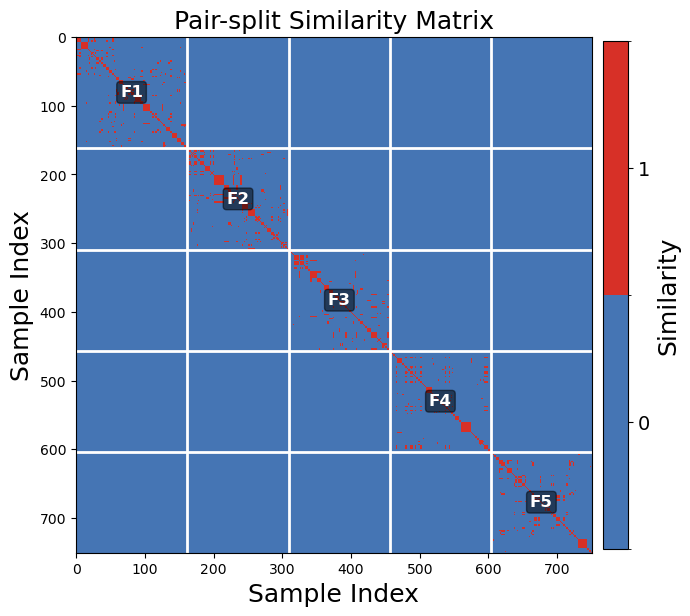

Saved: pair_similarity_matrix_by_fold.png

Cross-fold similarity check:
  Fold 0 vs Fold 1: 0/23976 similar pairs (0.00%)
  Fold 0 vs Fold 2: 0/23814 similar pairs (0.00%)
  Fold 0 vs Fold 3: 0/23814 similar pairs (0.00%)
  Fold 0 vs Fold 4: 0/23814 similar pairs (0.00%)
  Fold 1 vs Fold 2: 0/21756 similar pairs (0.00%)
  Fold 1 vs Fold 3: 0/21756 similar pairs (0.00%)
  Fold 1 vs Fold 4: 0/21756 similar pairs (0.00%)
  Fold 2 vs Fold 3: 0/21609 similar pairs (0.00%)
  Fold 2 vs Fold 4: 0/21609 similar pairs (0.00%)
  Fold 3 vs Fold 4: 0/21609 similar pairs (0.00%)


In [18]:
# ============== Pairwise Similarity Matrix (binary: share RNA seq or ligand) ==============
# Build sample list from saved data
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

samples = []  # list of (complex_key, rna_seq, ligand_id, fold_id)
for rna_key, rna_data in data_saved.items():
    for complex_key, sample_data in rna_data.items():
        train_split = sample_data.get('train_split')
        if train_split:
            test_fold = [i for i in range(5) if train_split[i] is False][0]
            rna_seq = sample_data.get('rna_chain_sequence', '')
            lig_id = sample_data.get('ligand_id', '')
            samples.append((complex_key, rna_seq, lig_id, test_fold))

n = len(samples)
print(f"Total samples: {n}")

# Sort by fold for block-diagonal structure
samples.sort(key=lambda x: x[3])
fold_ids = [s[3] for s in samples]
rna_seqs = [s[1] for s in samples]
lig_ids = [s[2] for s in samples]

# Build binary pairwise matrix: 1 if share same RNA sequence OR same ligand
print("Building pairwise similarity matrix...")

# Use vectorized approach with grouping for efficiency
rna_groups = {}
for i, seq in enumerate(rna_seqs):
    if seq not in rna_groups:
        rna_groups[seq] = []
    rna_groups[seq].append(i)

lig_groups = {}
for i, lig in enumerate(lig_ids):
    if lig not in lig_groups:
        lig_groups[lig] = []
    lig_groups[lig].append(i)

# Build sparse-style then fill matrix
sim_matrix = np.zeros((n, n), dtype=np.float32)
np.fill_diagonal(sim_matrix, 1.0)

for group_indices in rna_groups.values():
    if len(group_indices) > 1:
        idx = np.array(group_indices)
        sim_matrix[np.ix_(idx, idx)] = 1.0

for group_indices in lig_groups.values():
    if len(group_indices) > 1:
        idx = np.array(group_indices)
        sim_matrix[np.ix_(idx, idx)] = 1.0

print(f"Matrix shape: {sim_matrix.shape}")
print(f"Non-zero fraction: {(sim_matrix > 0).sum() / (n * n):.4f}")

# Find fold boundaries
fold_boundaries = []
for f in range(5):
    fold_start = fold_ids.index(f)
    fold_end = len(fold_ids) - 1 - fold_ids[::-1].index(f)
    fold_boundaries.append((fold_start, fold_end))

# ============== Plot ==============
# Binary colormap: 0 -> blue, 1 -> red
cmap_binary = mcolors.ListedColormap(['#4575b4', '#d73027'])
bounds = [-0.5, 0.5, 1.5]
norm_binary = mcolors.BoundaryNorm(bounds, cmap_binary.N)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(sim_matrix, cmap=cmap_binary, norm=norm_binary, aspect='equal', interpolation='nearest')
ax.set_title('Pair-split Similarity Matrix', fontsize=18)
ax.set_xlabel('Sample Index', fontsize=18)
ax.set_ylabel('Sample Index', fontsize=18)
cbar = fig.colorbar(im, ax=ax, shrink=1.0, pad=0.02, fraction=0.046, ticks=[0, 1])
cbar.set_label('Similarity', fontsize=18)
cbar.ax.set_yticklabels(['0', '1'], fontsize=14)

# Draw fold boundary lines and labels
for f, (start, end) in enumerate(fold_boundaries):
    if f > 0:
        ax.axhline(y=start - 0.5, color='white', linewidth=2)
        ax.axvline(x=start - 0.5, color='white', linewidth=2)
    mid = (start + end) / 2
    ax.text(mid, mid, f'F{f+1}', ha='center', va='center',
            fontsize=12, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))

plt.tight_layout()
plt.savefig('pair_similarity_matrix_by_fold.png', dpi=600, bbox_inches='tight')
plt.show()
print("Saved: pair_similarity_matrix_by_fold.png")

# Print cross-fold leakage stats
print("\nCross-fold similarity check:")
for fi in range(5):
    for fj in range(fi+1, 5):
        si, ei = fold_boundaries[fi]
        sj, ej = fold_boundaries[fj]
        cross_block = sim_matrix[si:ei+1, sj:ej+1]
        n_similar = (cross_block > 0).sum()
        total = cross_block.size
        print(f"  Fold {fi} vs Fold {fj}: {n_similar}/{total} similar pairs ({100*n_similar/total:.2f}%)")